### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics

In [119]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [100]:
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Constant

In [3]:
FOLD_PATH = './data/IntrusionDetectionSystemUsingMachineLearning/'

### Step 3: Load Data

In [4]:
with open(os.path.join(FOLD_PATH, 'kddcup.names.txt'), 'r') as f:
    cols = f.read().split('\n')[1:]
    columns = [col.split(':')[0] for col in cols if col != '']
columns.append('target')

In [5]:
len(columns)

42

In [6]:
with open(os.path.join(FOLD_PATH, 'training_attack_types.txt'), 'r') as f:
    attacks_types = {attacks_type.split(' ')[0]: attacks_type.split(' ')[1] for attacks_type in f.read().split('\n') if attacks_type != ''}
    attacks_types['normal'] = 'normal'

In [7]:
attacks_types

{'back': 'dos',
 'buffer_overflow': 'u2r',
 'ftp_write': 'r2l',
 'guess_passwd': 'r2l',
 'imap': 'r2l',
 'ipsweep': 'probe',
 'land': 'dos',
 'loadmodule': 'u2r',
 'multihop': 'r2l',
 'neptune': 'dos',
 'nmap': 'probe',
 'perl': 'u2r',
 'phf': 'r2l',
 'pod': 'dos',
 'portsweep': 'probe',
 'rootkit': 'u2r',
 'satan': 'probe',
 'smurf': 'dos',
 'spy': 'r2l',
 'teardrop': 'dos',
 'warezclient': 'r2l',
 'warezmaster': 'r2l',
 'normal': 'normal'}

In [8]:
df = pd.read_csv(os.path.join(FOLD_PATH, 'kddcup.data_10_percent_corrected'), names=columns)

In [9]:
df['Attack Type'] = df['target'].str[:-1].map(attacks_types)

In [10]:
df.shape

(494021, 43)

In [11]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


### Step 4: Exploaring Data

#### Basic Info

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,494021.0,47.979302,707.746472,0.0,0.00,0.0,0.00,58329.0
src_bytes,494021.0,3025.610296,988218.101045,0.0,45.00,520.0,1032.00,693375640.0
dst_bytes,494021.0,868.532425,33040.001252,0.0,0.00,0.0,0.00,5155468.0
land,494021.0,0.000045,0.006673,0.0,0.00,0.0,0.00,1.0
wrong_fragment,494021.0,0.006433,0.134805,0.0,0.00,0.0,0.00,3.0
urgent,494021.0,0.000014,0.005510,0.0,0.00,0.0,0.00,3.0
hot,494021.0,0.034519,0.782103,0.0,0.00,0.0,0.00,30.0
num_failed_logins,494021.0,0.000152,0.015520,0.0,0.00,0.0,0.00,5.0
logged_in,494021.0,0.148247,0.355345,0.0,0.00,0.0,0.00,1.0
num_compromised,494021.0,0.010212,1.798326,0.0,0.00,0.0,0.00,884.0


In [13]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100*df.isnull().sum()/len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [14]:
feature_info

,null,null(%),unique,type
duration,0,0.0,2495,int64
protocol_type,0,0.0,3,object
service,0,0.0,66,object
flag,0,0.0,11,object
src_bytes,0,0.0,3300,int64
dst_bytes,0,0.0,10725,int64
land,0,0.0,2,int64
wrong_fragment,0,0.0,3,int64
urgent,0,0.0,4,int64
hot,0,0.0,22,int64


#### Target Distribution

In [15]:
temp = df['Attack Type'].value_counts()

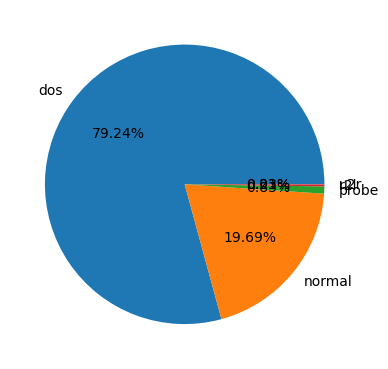

In [16]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index
)
plt.tight_layout()

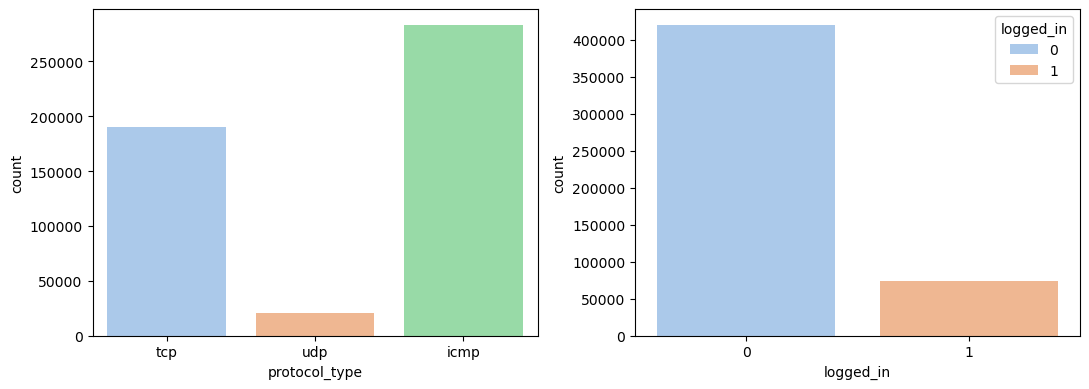

In [17]:
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='protocol_type', data=df, hue='protocol_type', palette='pastel')
plt.subplot(1, 2, 2)
sns.countplot(x='logged_in', data=df, hue='logged_in', palette='pastel')
plt.tight_layout()

### Step 5: Data Preprocessing

#### Handling Missing Value

In [22]:
df = df.dropna(axis='columns')

#### Split Data

In [23]:
df = df.drop(['target'], axis=1)

In [36]:
valid_cols = [col for col in df.columns if df[col].nunique() > 1]

In [37]:
df = df[valid_cols]

In [72]:
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

#### Feature Encoding

In [77]:
object_cols = X_train.select_dtypes(include='object').columns

In [80]:
feature_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', 
    unknown_value=-1
)

In [83]:
X_train[object_cols] = feature_encoder.fit_transform(X_train[object_cols])

In [85]:
X_test[object_cols] = feature_encoder.transform(X_test[object_cols])

#### Label Encoding

In [89]:
le = LabelEncoder()

In [91]:
y_train = le.fit_transform(y_train)

In [92]:
y_test = le.transform(y_test)

#### Correlation Analysis

In [94]:
corr = X_train.corr()

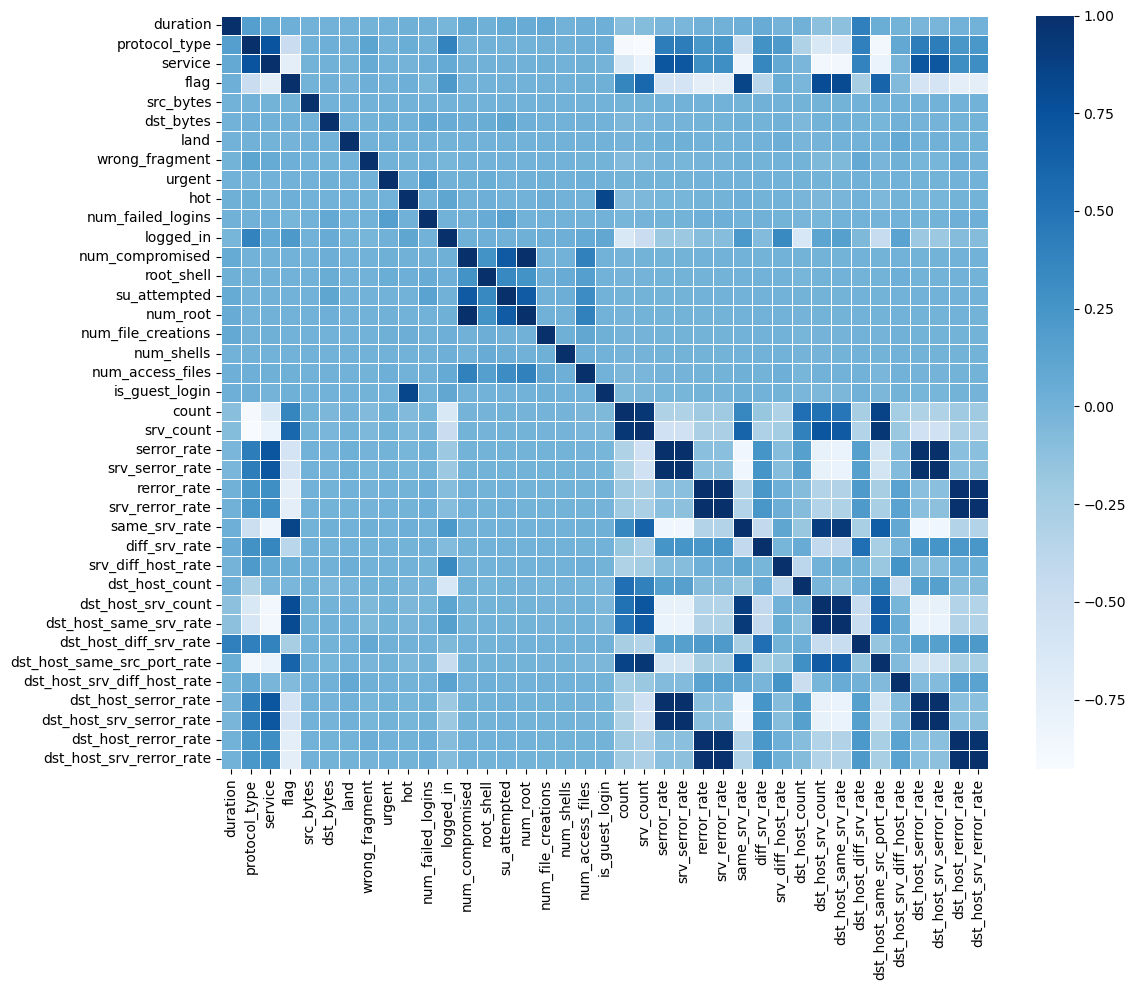

In [99]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap=plt.cm.Blues,
    linewidths=0.5
)
plt.tight_layout()

#### Select Features

In [102]:
raw_feature_cols = X_train.columns.to_list()

In [101]:
selector = SmartCorrelatedSelection(
    threshold=0.8, 
    selection_method='corr_with_target'
)

In [106]:
X_train = selector.fit_transform(X_train, y_train)

In [113]:
X_test = X_test[deal_feature_cols]

In [107]:
deal_feature_cols = X_train.columns.to_list()

In [110]:
delete_feature_cols = list(set(raw_feature_cols) - set(deal_feature_cols))

In [111]:
print('raw featuers:', raw_feature_cols)
print('deal featuers:', deal_feature_cols)
print('delete featuers:', delete_feature_cols)

raw featuers: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
deal featuers: ['duration', 'protocol_type', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'rerror_rate', 'diff_srv_rate', 'srv_diff

In [114]:
corr = X_train.corr()

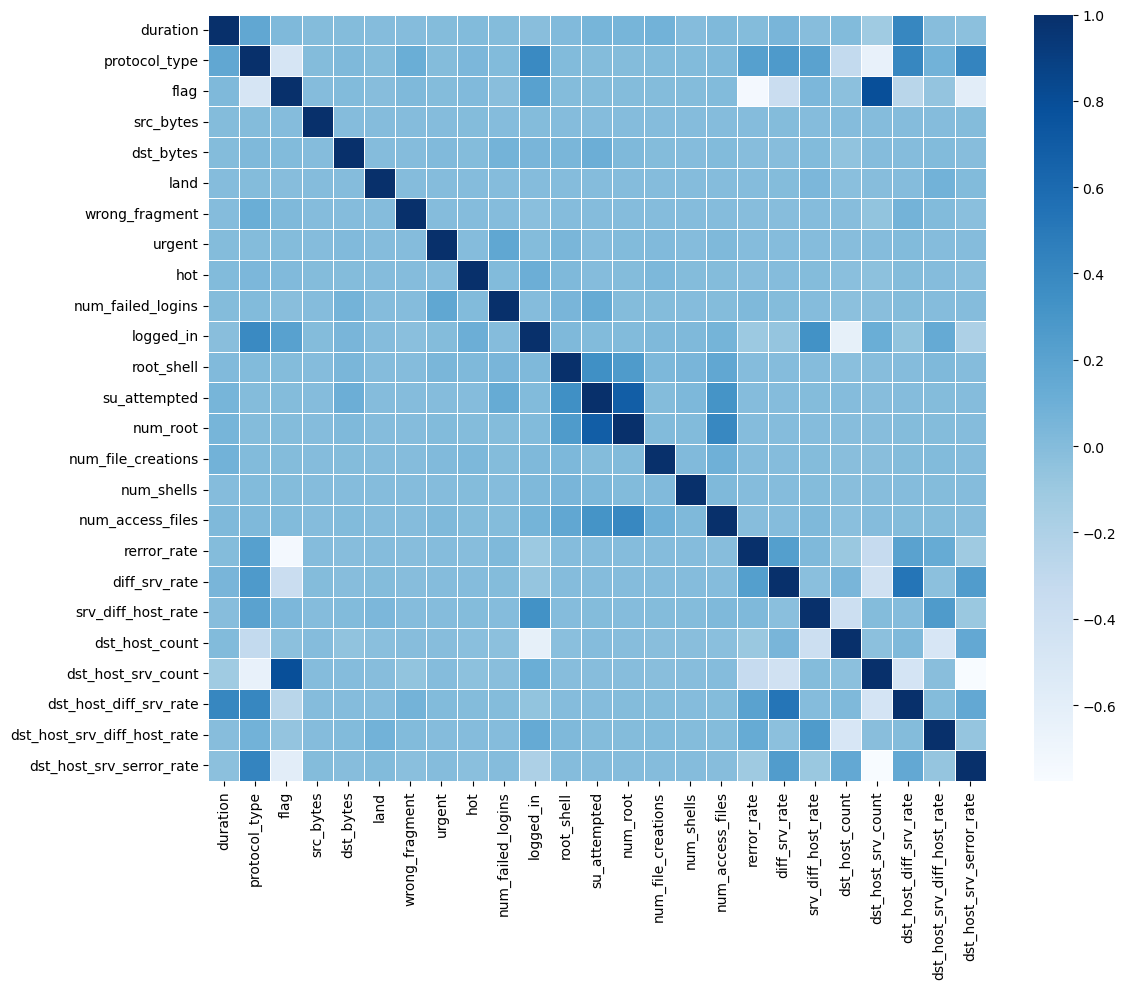

In [115]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap=plt.cm.Blues,
    linewidths=0.5
)
plt.tight_layout()

#### Scaling Data

In [116]:
sc = StandardScaler()

In [117]:
X_train = sc.fit_transform(X_train)

In [118]:
X_test = sc.transform(X_test)

### Step 6: Model Development

#### Build Model

In [127]:
models = [
    GaussianNB(), 
    DecisionTreeClassifier(criterion='entropy'),
    RandomForestClassifier(n_estimators=30),
    SVC(),
    LogisticRegression(),
    GradientBoostingClassifier(random_state=42)
]

In [131]:
for model in models:
    print(model.__class__.__name__)
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='accuracy',
        cv=5,
        error_score='raise'
    )
    print('training accurary scores:', [round(float(score), 3) for score in scores])
    print('training accurary score:', round(scores.mean(), 3))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('testing accuracy score:', round(metrics.accuracy_score(y_test, y_pred), 3))
    print('-' * 20)

GaussianNB
training accurary scores: [0.822, 0.857, 0.731, 0.859, 0.891]
training accurary score: 0.832
testing accuracy score: 0.86
--------------------
DecisionTreeClassifier
training accurary scores: [1.0, 1.0, 1.0, 1.0, 1.0]
training accurary score: 1.0
testing accuracy score: 1.0
--------------------
RandomForestClassifier
training accurary scores: [1.0, 1.0, 1.0, 1.0, 1.0]
training accurary score: 1.0
testing accuracy score: 1.0
--------------------
SVC
training accurary scores: [0.999, 0.999, 0.998, 0.999, 0.998]
training accurary score: 0.998
testing accuracy score: 0.999
--------------------
LogisticRegression
training accurary scores: [0.99, 0.991, 0.99, 0.99, 0.99]
training accurary score: 0.99
testing accuracy score: 0.99
--------------------
GradientBoostingClassifier
training accurary scores: [0.999, 0.999, 0.998, 0.999, 0.999]
training accurary score: 0.999
testing accuracy score: 0.999
--------------------


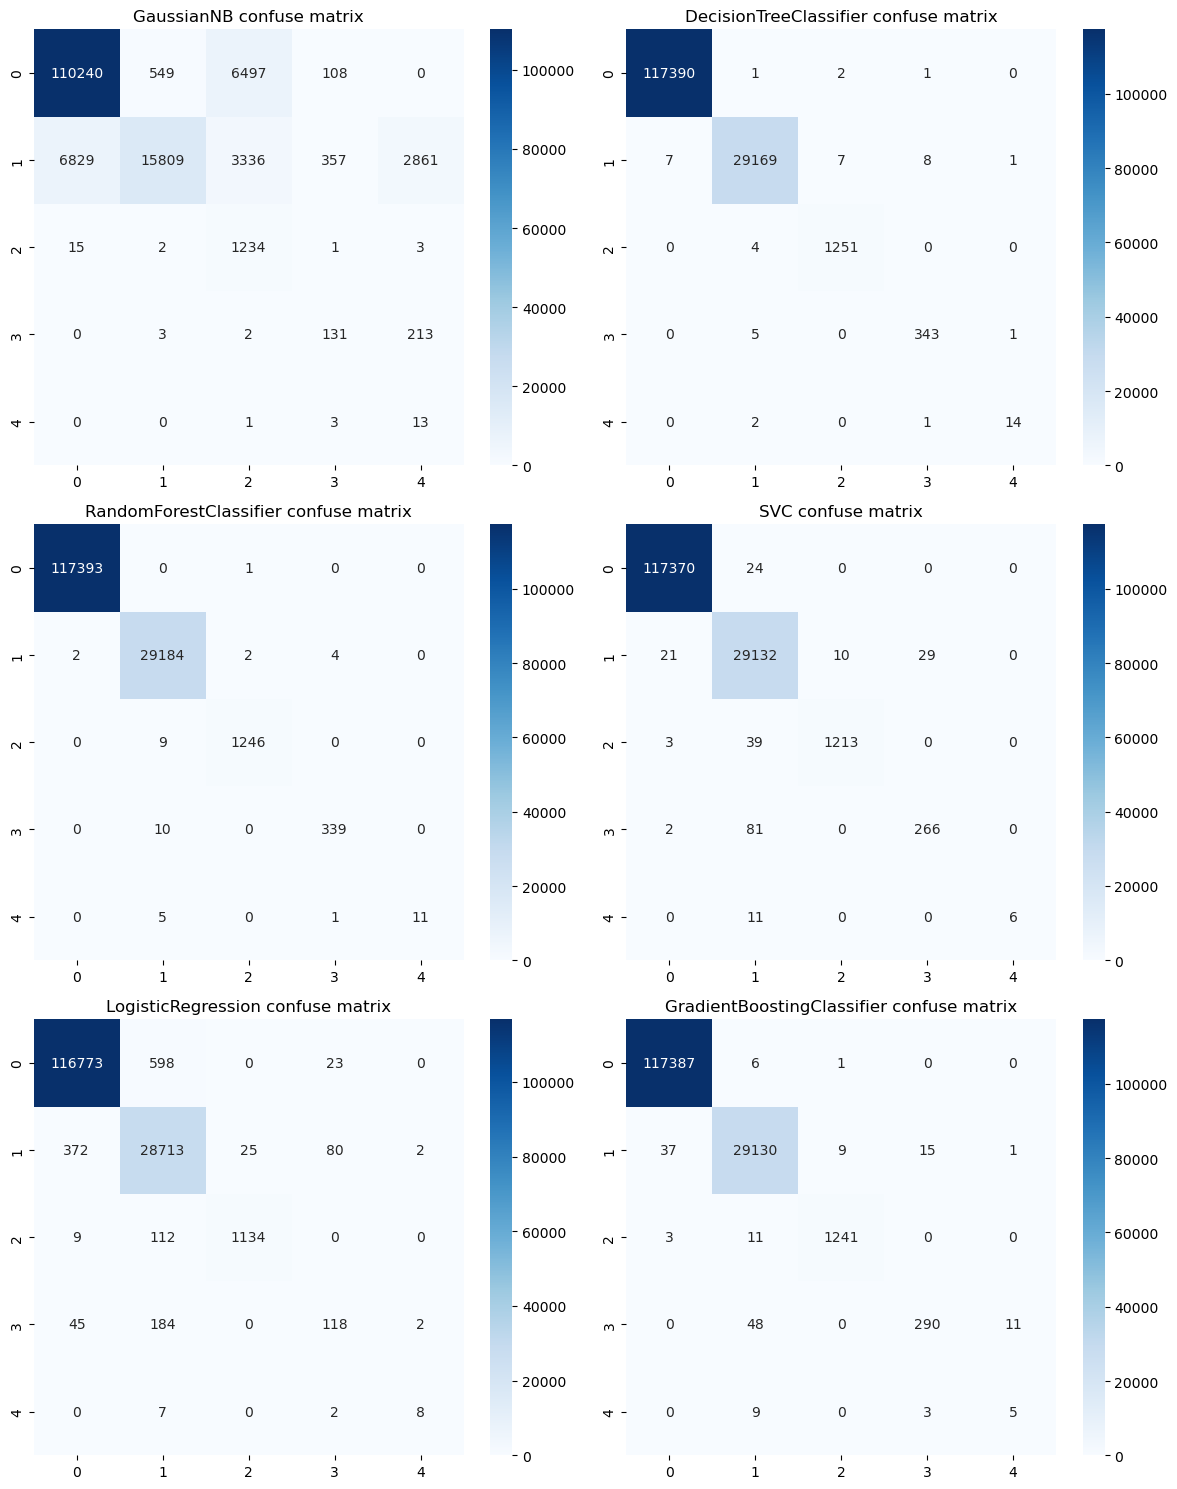

In [134]:
plt.figure(figsize=(12, 15))
for i, model in enumerate(models):
    plt.subplot(3, 2, i+1)
    cm = metrics.confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm,
        fmt='d',
        annot=True,
        cmap=plt.cm.Blues
    )
    plt.title(f'{model.__class__.__name__} confuse matrix')
plt.tight_layout()

In [135]:
for model in models:
    print('-'*20, model.__class__.__name__, '-'*20)
    print(metrics.classification_report(y_test, model.predict(X_test)))

-------------------- GaussianNB --------------------
              precision    recall  f1-score   support

           0       0.94      0.94      0.94    117394
           1       0.97      0.54      0.69     29192
           2       0.11      0.98      0.20      1255
           3       0.22      0.38      0.28       349
           4       0.00      0.76      0.01        17

    accuracy                           0.86    148207
   macro avg       0.45      0.72      0.42    148207
weighted avg       0.94      0.86      0.88    148207

-------------------- DecisionTreeClassifier --------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       0.99      1.00      0.99      1255
           3       0.97      0.98      0.98       349
           4       0.88      0.82      0.85        17

    accuracy                           1.00    148207
   macro avg 